# Introduction to Regression

Welcome! In this lesson we will introduce **regression** as a supervised learning task for predicting **continuous** outcomes. We’ll set the stage for the course, outline the models we will study, and load our first dataset (the *Diabetes* dataset from `scikit-learn`).

**Learning objectives**
- Understand the goal of regression and how it differs from classification.
- Recognize common regression model families and when to use them.
- Get familiar with the Diabetes dataset we will use throughout the first part of the course.
- Perform a light **EDA** (exploratory data analysis) to understand features and the target.



**Prerequisites**
- Basic Python (e.g., Intro to Python / Software Carpentry) and fundamental statistics.
- No prior machine learning experience is required.


## What is Regression? How is it different from Classification?

- **Regression:** predict a *continuous value* (e.g., blood pressure, medical costs).
- **Classification:** predict a *category/label* (e.g., healthy vs. sick).


We assume a data-generating process of the form
$$
\hat{y} = f(X) + \varepsilon
$$
where:
- $\hat{y}$ is the model’s prediction for the target $y$,
- $X \in \mathbb{R}^{n \times p}$ is the feature matrix with $n$ samples and $p$ features,
- $f(\cdot)$ is the (unknown) function we wish to approximate,
- $\varepsilon$ is random noise (mean zero, finite variance).

### Common Model Families We Will Study
1. **Linear models** (e.g., Ordinary Least Squares)
2. **Regularized linear models** (Ridge, Lasso)
3. **Tree-based models** (Decision Tree, Random Forest)
4. **Neural networks** (Multi-Layer Perceptron for regression)

Each family captures different types of relationships and trade-offs between **bias**, **variance**, and **interpretability**.



## Bias–Variance (Intuition)

When choosing models, we balance **bias** (error from overly simple assumptions) and **variance** (error from sensitivity to the specific training data).

The **expected generalization error** can be decomposed (for squared loss) into bias, variance, and irreducible noise:
$$
\mathbb{E}\left[(y - \hat{f}(X))^2\right] = \underbrace{\text{Bias}^2}_{\text{underfitting}} + \underbrace{\text{Variance}}_{\text{overfitting}} + \underbrace{\sigma^2}_{\text{noise}}.
$$

- **High bias** $\rightarrow$ underfitting (model too simple).
- **High variance** $\rightarrow$ overfitting (model too complex).
- We will use **evaluation metrics** and **diagnostic plots** (e.g., residual plots, learning curves) to reason about this balance.



## Datasets Used in This Course

We will start with the **Diabetes** dataset that ships with `scikit-learn` (small, clean, numeric). Later, we will bring in the **Medical Insurance** dataset (real-world, mixed numeric & categorical features) to practice preprocessing and feature engineering.

**Diabetes dataset (regression)**
- **Target**: Quantitative measure of disease progression one year after baseline.
- **Features**: 10 baseline variables such as age, sex, BMI, blood pressure, and serum measurements.
- **Why start here?** Small, quick to train, great for teaching core concepts.

**Medical Insurance dataset (regression)** *(used later)*
- **Target**: `charges` (medical insurance costs)
- **Features**: `age`, `sex`, `bmi`, `children`, `smoker`, `region` (requires encoding)
- **Why later?** Demonstrates categorical encoding, interactions, and non-linear effects.


In [ ]:
# Install required libraries
# !pip install pandas matplotlib scikit-learn

In [5]:
# Load and preview the Diabetes dataset (built into scikit-learn)
from sklearn.datasets import load_diabetes
import pandas as pd

data = load_diabetes(as_frame=True)
df = data.frame.copy()  # includes features and target under 'target'
df.rename(columns={'target': 'disease_progression'}, inplace=True)

print("Shape:", df.shape)
df.head()

Shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0



### Feature Glossary (from `sklearn.datasets.load_diabetes`)

- `age`: age in years (standardized)
- `sex`: sex (standardized)
- `bmi`: body mass index (standardized)
- `bp`: average blood pressure (standardized)
- `s1`–`s6`: six serum measurements (standardized)
- `disease_progression` (target): a quantitative measure of disease progression one year after baseline

> Note: Features are already standardized (mean ~0, variance ~1). This helps many models converge quickly and makes coefficients comparable in linear models.


In [6]:
# Basic EDA
df.describe(include='all')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000



### First Look: What to Notice
- **Scales**: Here they are standardized, which simplifies model training.
- **Distributions**: Skewness/heavy tails can affect error metrics (e.g., MAE vs RMSE).
- **Target behavior**: Understanding the spread of `disease_progression` will help interpret errors later.


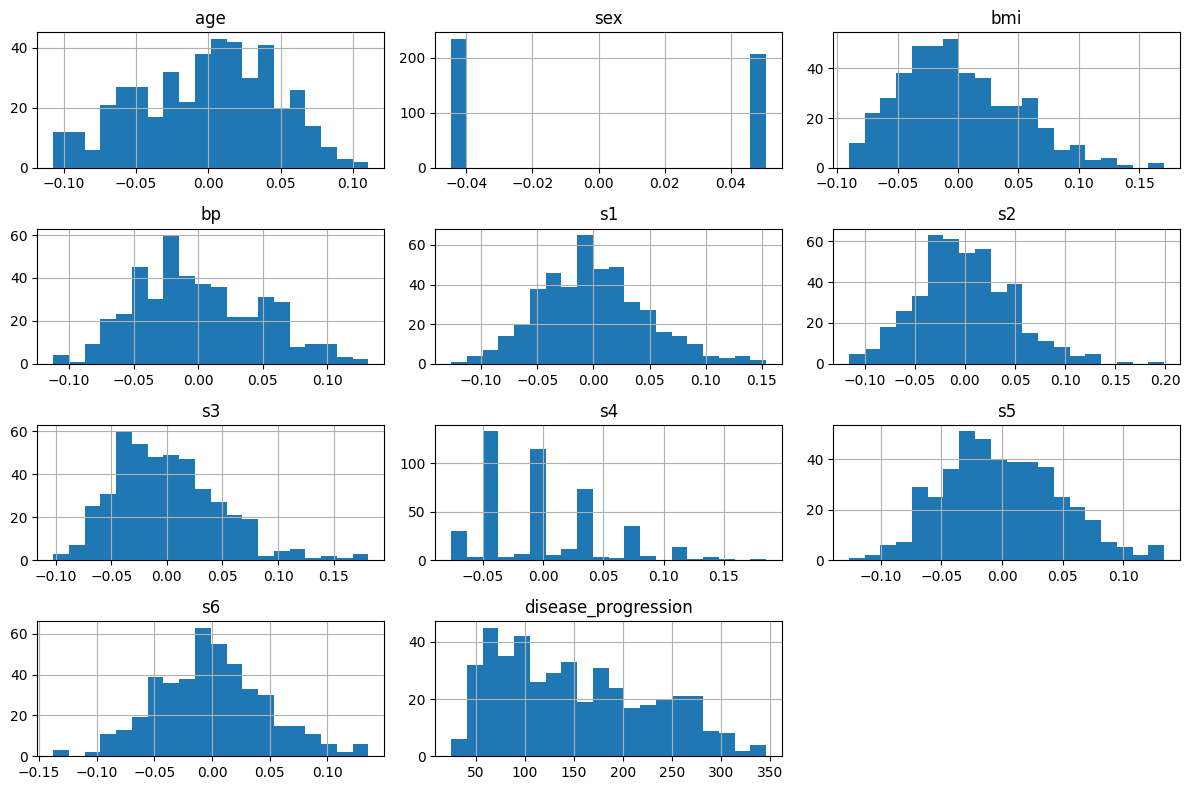

In [3]:
# Histograms for features and target
import matplotlib.pyplot as plt

_ = df.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()


**Why histograms?**
- Quick sense of distribution shape (normality, skewness, outliers).
- Helps anticipate when certain models/metrics might struggle.


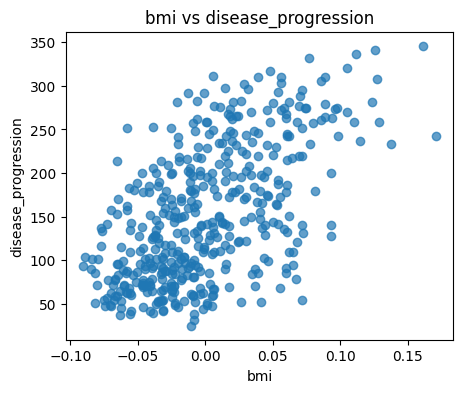

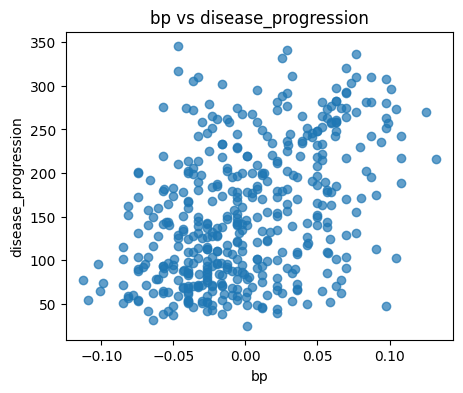

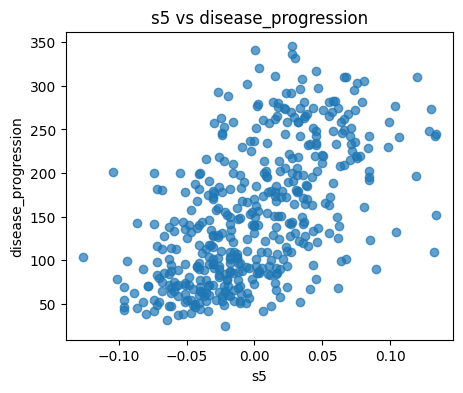

In [4]:
# Scatter plots: individual features vs target
import matplotlib.pyplot as plt

features_to_plot = ['bmi', 'bp', 's5']
for col in features_to_plot:
    plt.figure(figsize=(5,4))
    plt.scatter(df[col], df['disease_progression'], alpha=0.7)
    plt.xlabel(col)
    plt.ylabel('disease_progression')
    plt.title(f'{col} vs disease_progression')
    plt.show()


**Reading these plots**
- A **monotonic trend** (up or down) suggests a linear component.
- **Curvature** suggests possible non-linear relationships (trees, interactions, neural nets may help).
- **Heteroscedasticity** (variance changing with $x$) foreshadows issues for ordinary least squares assumptions.



## What Comes Next

In the next notebook, we will fit a **Linear Regression** model on this dataset and discuss:
- The linear model $\hat{y} = \beta_0 + \sum_{j=1}^p \beta_j x_j$
- Ordinary Least Squares (OLS) objective and closed-form solution
- Interpreting coefficients and *assumptions*
- First set of **evaluation metrics** and **diagnostic plots** (moved fully to the following notebook)

We will then follow with a dedicated **Model Evaluation** notebook to build robust instincts for diagnosing bias/variance, under/overfitting, and when to consider regularization or non-linear models.



## Short Exercises (Optional)

1. Using the scatter plots above, which feature seems most correlated with `disease_progression`? Why?
2. Compute the correlation matrix and identify the top-3 features most correlated with the target.


In [6]:
# (Optional) Correlation matrix to support Exercise 2
corr = df.corr(numeric_only=True)
display(corr)
corr['disease_progression'].sort_values(ascending=False)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


disease_progression    1.000000
bmi                    0.586450
s5                     0.565883
bp                     0.441482
s4                     0.430453
s6                     0.382483
s1                     0.212022
age                    0.187889
s2                     0.174054
sex                    0.043062
s3                    -0.394789
Name: disease_progression, dtype: float64